In [1]:
import sys
print(sys.executable)

C:\Users\koppi\OneDrive\Documents\ML\House-Price-Prediction\venv\Scripts\python.exe


## House Price Prediction
### Exploratory Data Analysis (EDA)
Project-2 Linear Regression

In [2]:
import pandas as pd
df = pd.read_csv("../data/housing.csv")

In [3]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [4]:
df.columns
# see column names - each column is each property that describes a house

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='str')

In [5]:
# Target variable from above columns is Price - model predicts this
# remaining columns are features - input variables we give to model
df["Price"] # looking at a single column

0       1.059034e+06
1       1.505891e+06
2       1.058988e+06
3       1.260617e+06
4       6.309435e+05
            ...     
4995    1.060194e+06
4996    1.482618e+06
4997    1.030730e+06
4998    1.198657e+06
4999    1.298950e+06
Name: Price, Length: 5000, dtype: float64

In [6]:
df[["Area Population", "Price"]] # looking at multiple columns

,Area Population,Price
0,23086.80050,1.059034e+06
1,40173.07217,1.505891e+06
2,36882.15940,1.058988e+06
3,34310.24283,1.260617e+06
4,26354.10947,6.309435e+05
...,...,...
4995,22837.36103,1.060194e+06
4996,25616.11549,1.482618e+06
4997,33266.14549,1.030730e+06
4998,42625.62016,1.198657e+06


In [7]:
df.dtypes
# check datatypes

Avg. Area Income                float64
Avg. Area House Age             float64
Avg. Area Number of Rooms       float64
Avg. Area Number of Bedrooms    float64
Area Population                 float64
Price                           float64
Address                             str
dtype: object

In [8]:
df["Address"].head()

0    208 Michael Ferry Apt. 674\nLaurabury, NE 3701...
1    188 Johnson Views Suite 079\nLake Kathleen, CA...
2    9127 Elizabeth Stravenue\nDanieltown, WI 06482...
3                            USS Barnett\nFPO AP 44820
4                           USNS Raymond\nFPO AE 09386
Name: Address, dtype: str

In [9]:
df = df.drop("Address", axis=1)
# delete address column because we don't need it and linear regression model operates on numerical values not text

In [10]:
# seperating inputs and output
X = df.drop("Price", axis=1)
y = df["Price"]

In [11]:
# check X and y
X.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,79545.45857,5.682861,7.009188,4.09,23086.80050
1,79248.64245,6.002900,6.730821,3.09,40173.07217
2,61287.06718,5.865890,8.512727,5.13,36882.15940
3,63345.24005,7.188236,5.586729,3.26,34310.24283
4,59982.19723,5.040555,7.839388,4.23,26354.10947


In [12]:
y.head()

0    1.059034e+06
1    1.505891e+06
2    1.058988e+06
3    1.260617e+06
4    6.309435e+05
Name: Price, dtype: float64

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
model = LinearRegression()

In [17]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 21.65,164666.48,119624.01, 2440.38, 15.27]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Avg. Area Income','Avg. Area House Age','Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms','Area Population']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.635e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [18]:
y_pred = model.predict(X_test)

In [19]:
for actual, pred in list(zip(y_test[:5], y_pred[:5])):
    print("Actual :", actual, "Predicted: ", pred)

Actual : 1339096.077 Predicted:  1308587.9271845385
Actual : 1251794.179 Predicted:  1237037.2295026998
Actual : 1340094.966 Predicted:  1243429.340230362
Actual : 1431507.623 Predicted:  1228900.2136875857
Actual : 1042373.524 Predicted:  1063320.907316016


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
import numpy as np

In [22]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [23]:
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2_Score:", r2)

MAE: 80879.09722218332
MSE: 10089009299.49946
RMSE: 100444.060548643
R2_Score: 0.9179971706985317


In [24]:
import sys
print(sys.executable)

C:\Users\koppi\OneDrive\Documents\ML\House-Price-Prediction\venv\Scripts\python.exe


In [25]:
import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import matplotlib.pyplot as plt

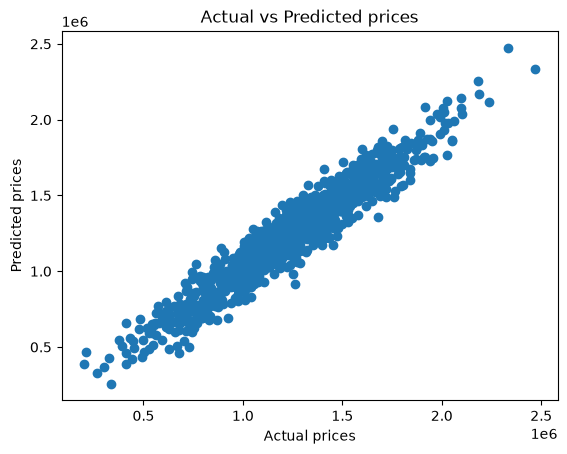

In [27]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual prices")
plt.ylabel("Predicted prices")
plt.title("Actual vs Predicted prices")
plt.show()

In [28]:
residuals = y_test - y_pred

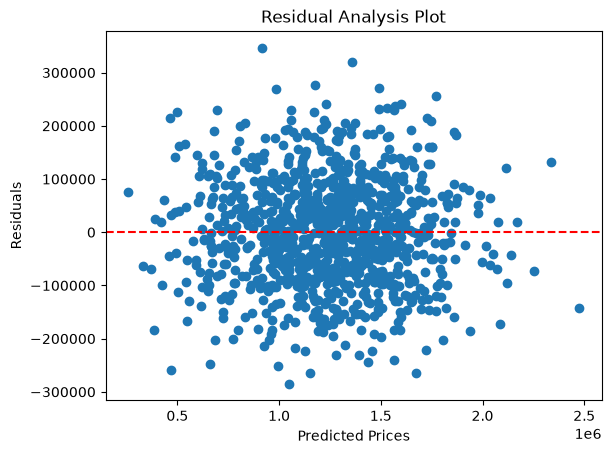

In [29]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Analysis Plot")
plt.show()

In [30]:
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import seaborn as sns

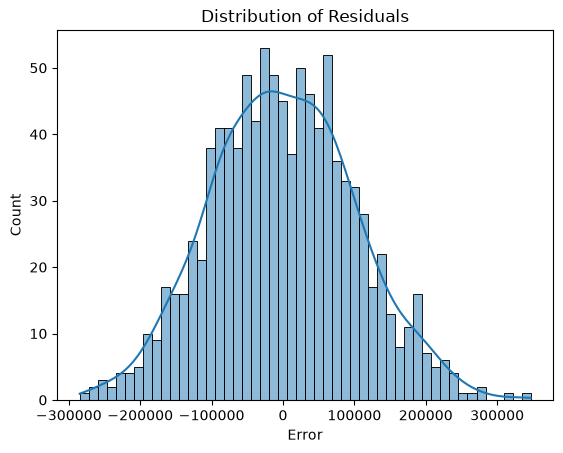

In [32]:
sns.histplot(residuals, bins=50, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Error")
plt.show()

## Model Improvement Basics (Experiments)

### Experiment-1 : Data (or Log) Transformation
**Why we are doing th is?**  
Linear Regression performs better when target variable is approximately normally distributed. If house prices are highly skewed, applying a log transformation can reduce skewness and sometimes improve model performance.

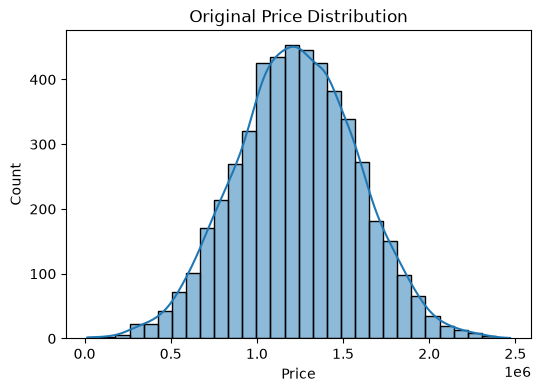

In [33]:
# Original Price Distribution Plot
plt.figure(figsize=(6, 4))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Original Price Distribution")
plt.show()

**-> Apply Log Transformation on Price column**  
**Why we are doing this?**  
The logarithm compresses very large values more than small values, reducing the effect of extreme house prices and making the distribution more symmetric.

In [34]:
import numpy as np
df["Log_Price"] = np.log(df["Price"])
# or log(y)

**-> Visualize the Transformed Target**  
**Why we are doing this?**  
Compare the original and transformed distributions to check whether the log transformation reduced skewness.

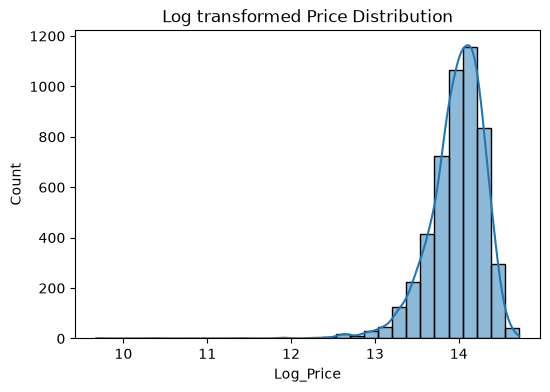

In [35]:
plt.figure(figsize=(6, 4))
sns.histplot(df["Log_Price"], bins=30, kde=True)
plt.title("Log transformed Price Distribution")
plt.show()

### Comparison: Original Price Distribution vs Log Transformed Price Distribution

**Original Price Distribution**  
- The house prices are spread over a wide range.  
- A few expensive houses create a longer tail on the right side.  
- The distribution is close to a bell shape but is slightly right-skewed.  
- Large price values have a greater influence on the model.  

**Log Transformed Price Distribution**
- The logarithm compresses large house prices more than smaller prices.
- The overall spread of the data becomes smaller.
- Extreme price values have less influence on the model.
- The distribution becomes more compact, although in this dataset it is not significantly more normal than the original distribution.

**Observation**
In this dataset, the original price distribution is already approximately bell-shaped. Therefore, applying a log transformation does not provide a major improvement. Log transformation is generally more useful when the original target variable is highly skewed.

### Experiment-2 : Feature Scaling
**Why are we doing this?**  
ML features often have different ranges. Feature scaling standardizes the features so they have a mean of 0 and a standard deviation of 1. Some ML algorithms perform better when features are on a similar scale.

In [36]:
X.describe()
# we do it bcz describe() is a pandas function that automatically calculates statistics 
# count, mean, std(standard deviation), min, max etc for each column(feature_name)

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039
std,10657.991214,0.991456,1.005833,1.234137,9925.650114
min,17796.631190,2.644304,3.236194,2.000000,172.610686
25%,61480.562390,5.322283,6.299250,3.140000,29403.928700
50%,68804.286405,5.970429,7.002902,4.050000,36199.406690
75%,75783.338665,6.650808,7.665871,4.490000,42861.290770
max,107701.748400,9.519088,10.759588,6.500000,69621.713380


**-> Apply Standard scaling**  
**Why are we doing this?**  
StandardScaler learns the mean and standard deviation of each feature and transforms the data into standardized values.

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**-> Convert Scaled Data into a DataFrame**  
**Why we are doing this?**  
fit_transforms() returns a NumPy array. Converting it back to a DataFrame makes the scaled values easier to inspect while preserving the original column names.

In [38]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,1.028660,-0.296927,0.021274,0.088062,-1.317599
1,1.000808,0.025902,-0.255506,-0.722301,0.403999
2,-0.684629,-0.112303,1.516243,0.930840,0.072410
3,-0.491499,1.221572,-1.393077,-0.584540,-0.186734
4,-0.807073,-0.944834,0.846742,0.201513,-0.988387


**-> Train Linear Regression Model Using Scaled Features**  
**Why are we doing this?**  
After applying feature scaling, we train another Linear Regression model using the scaled features. This allows us to compare the performance of the original model and the scaled model to determine whether feature scaling improves prediction accuracy.

In [39]:
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.4,
    random_state=101
)
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = model_scaled.predict(X_test_scaled)
print("R2_Score_Scaled:", r2_score(y_test, y_pred_scaled))

R2_Score_Scaled: 0.9176824009781773


### Comparison: Model Performance Before and After Feature Scaling

**R² Score (Without Feature Scaling)**  
- **0.9179971706985317**  

**R² Score (With Feature Scaling)**  
- **0.9176824009781773**  

**Observation**  

The R² scores before and after feature scaling are almost identical. The scaled model shows a very small decrease in performance, which is practically insignificant.

**Conclusion**  

Feature scaling did not improve the performance of the Linear Regression model for this dataset. This is expected because Linear Regression is generally not sensitive to the scale of input features. Unlike algorithms such as K-Nearest Neighbors (KNN), Support Vector Machines (SVM), and Neural Networks, Linear Regression can produce similar results even when the features have different ranges.

Therefore, feature scaling is **not necessary** for this Linear Regression model, although it remains an important preprocessing step for many other machine learning algorithms.

## Saving and Loading Machine Learning Models
**Why Save the Model?**  
A trained machine learning model exists only in memory while the Python program is running. Once the notebook is closed, the trained model is lost.  
Instead of training the model every time, we save it to disk and load it whenever predictions are needed. This makes machine learning applications faster and more efficient.  
In this project, we will use the **Joblib** library to save and load the trained Linear Regression model.

In [40]:
import joblib

In [41]:
joblib.dump(model, "../models/house_price_model.joblib")

['../models/house_price_model.joblib']

## Loading the Saved Model
**Why are we loading the model?**  
Instead of training the model every time, we can load the previously saved model from disk. This allows us to make predictions instantly without repeating the training process.  
Loading a saved model is the standard workflow used in real-world machine learning applications.

In [43]:
loaded_model = joblib.load("../models/house_price_model.joblib")

## Verify the Loaded Model
To ensure that the model has been loaded correctly, we use it to make predictions on the test data and compare the results with the original trained model.

In [44]:
y_pred_loaded = loaded_model.predict(X_test)

In [45]:
print(y_pred[:5])
print(y_pred_loaded[:5])

[1308587.92718454 1237037.2295027  1243429.34023036 1228900.21368759
 1063320.90731602]
[1308587.92718454 1237037.2295027  1243429.34023036 1228900.21368759
 1063320.90731602]


**Result:**  
Both model and loaded_model gave identical predictions. This means saved model preserved everything it learned during training.